---
## 1. Import Libraries

In [32]:
# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

 Libraries imported successfully!


---
## 2. Load & Explore Data

In [2]:
# Load the dataset
df = pd.read_csv('D:\\Github Projects\\titanic-ml-project\\data\\Titanic-Dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First 5 rows:")
print("="*50)
df.head()

Dataset Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Dataset information
print("="*50)
print("Dataset Info:")
print("="*50)
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
# Statistical summary
print("="*50)
print("Statistical Summary:")
print("="*50)
df.describe()

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Check missing values
print("="*50)
print("Missing Values:")
print("="*50)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing Values'] > 0])

Missing Values:
          Missing Values  Percentage
Cabin                687   77.104377
Age                  177   19.865320
Embarked               2    0.224467


### Key Observations:
- **Cabin**: 77% missing values - may need to be dropped or heavily processed
- **Age**: 20% missing values - can be imputed
- **Embarked**: <1% missing values - easy to fill

---
## 3. Data Preprocessing

In [7]:
# Create a copy for preprocessing
df_processed = df.copy()

# Handle missing values
print("Handling Missing Values...")

# 1. Fill Age with median (grouped by Pclass and Sex)
df_processed['Age'] = df_processed.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Fill Embarked with mode
df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)

# 3. Fill Fare with median
df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)

# 4. Create 'Has_Cabin' feature from Cabin
df_processed['Has_Cabin'] = df_processed['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# 5. Extract deck from Cabin
df_processed['Deck'] = df_processed['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'U')

print(" Missing values handled!")
print("\nRemaining missing values:")
print(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])

Handling Missing Values...
 Missing values handled!

Remaining missing values:
Cabin       687
Embarked      2
dtype: int64


In [9]:
# Encode categorical variables
print("Encoding Categorical Variables...")

# Label encode binary variables
le_sex = LabelEncoder()
df_processed['Sex'] = le_sex.fit_transform(df_processed['Sex'])  # male=1, female=0

# One-hot encode Embarked and Deck
df_processed = pd.get_dummies(df_processed, columns=['Embarked', 'Deck'], prefix=['Embarked', 'Deck'])

print("Categorical variables encoded!")
print("\nNew columns created:")
print([col for col in df_processed.columns if col.startswith(('Embarked_', 'Deck_'))])

Encoding Categorical Variables...
Categorical variables encoded!

New columns created:
['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U']


---
## 4. Exploratory Data Analysis (EDA)

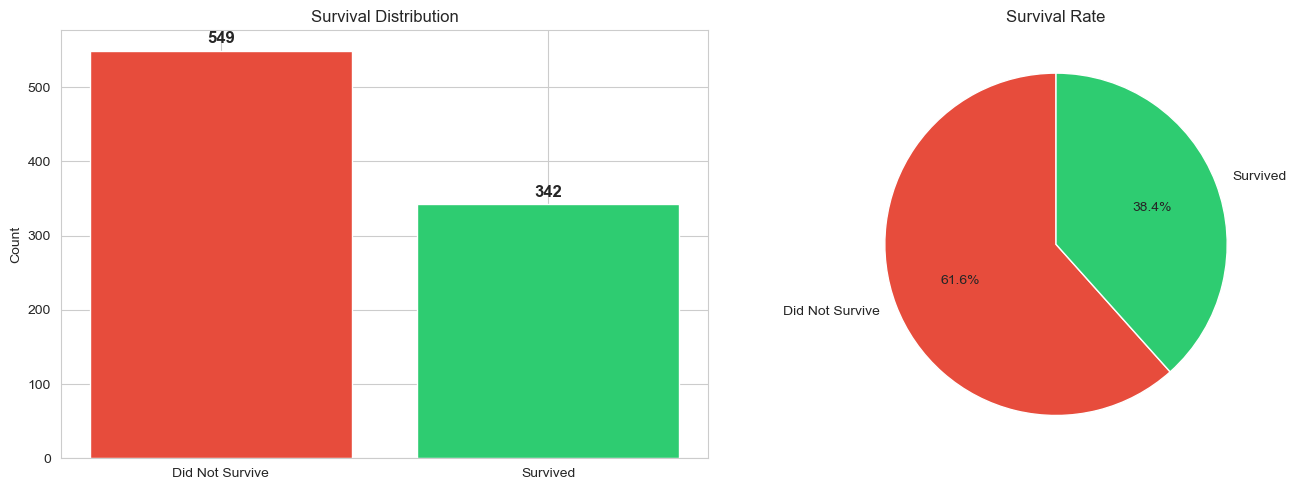

Survival Rate: 38.4%


In [10]:
# Survival distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
survival_counts = df['Survived'].value_counts()
axes[0].bar(['Did Not Survive', 'Survived'], survival_counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_ylabel('Count')
axes[0].set_title('Survival Distribution')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(survival_counts.values, labels=['Did Not Survive', 'Survived'], 
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Survival Rate')

plt.tight_layout()
plt.savefig('../images/survival_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Survival Rate: {(df['Survived'].sum() / len(df) * 100):.1f}%")

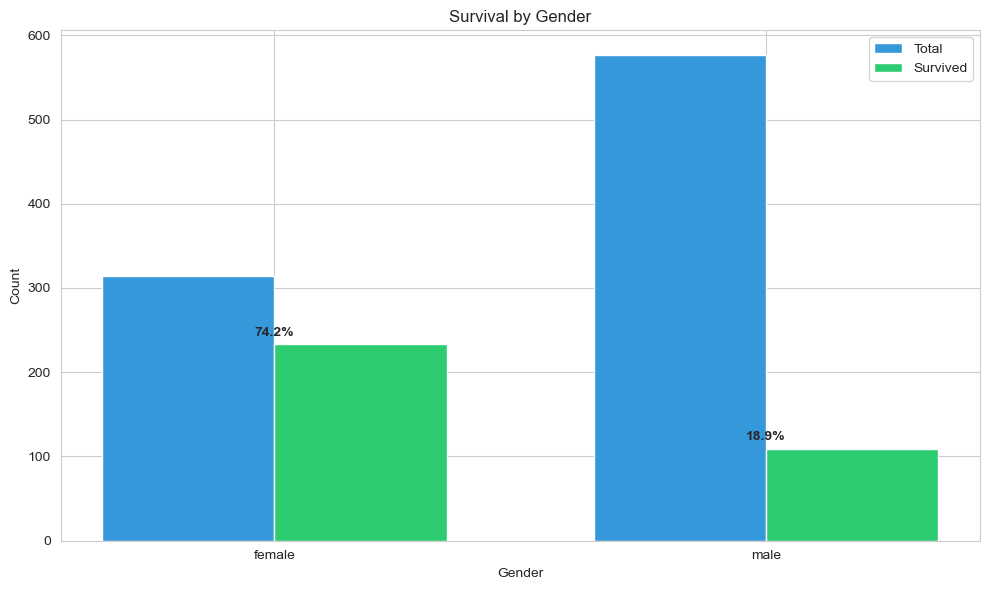

      Sex  Total  Survived  Survival_Rate
0  female    314       233       0.742038
1    male    577       109       0.188908


In [11]:
# Survival by Gender
fig, ax = plt.subplots(figsize=(10, 6))

survival_by_sex = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
survival_by_sex.columns = ['Sex', 'Total', 'Survived', 'Survival_Rate']

x = np.arange(len(survival_by_sex))
width = 0.35

bars1 = ax.bar(x - width/2, survival_by_sex['Total'], width, label='Total', color='#3498db')
bars2 = ax.bar(x + width/2, survival_by_sex['Survived'], width, label='Survived', color='#2ecc71')

ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_title('Survival by Gender')
ax.set_xticks(x)
ax.set_xticklabels(survival_by_sex['Sex'])
ax.legend()

# Add percentage labels
for i, (total, survived) in enumerate(zip(survival_by_sex['Total'], survival_by_sex['Survived'])):
    rate = survived / total * 100
    ax.text(i, survived + 10, f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/survival_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

print(survival_by_sex)

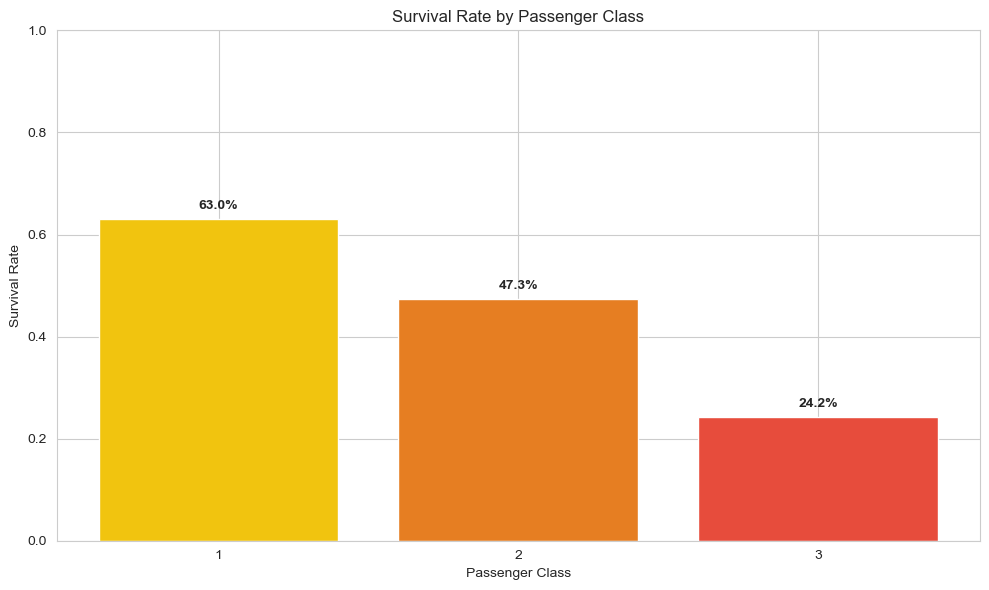

   Pclass  Total  Survived  Survival_Rate
0       1    216       136       0.629630
1       2    184        87       0.472826
2       3    491       119       0.242363


In [12]:
# Survival by Passenger Class
fig, ax = plt.subplots(figsize=(10, 6))

survival_by_class = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).reset_index()
survival_by_class.columns = ['Pclass', 'Total', 'Survived', 'Survival_Rate']

colors = ['#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(survival_by_class['Pclass'], survival_by_class['Survival_Rate'], color=colors)

ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate')
ax.set_title('Survival Rate by Passenger Class')
ax.set_ylim(0, 1)
ax.set_xticks([1, 2, 3])

# Add percentage labels
for bar, rate in zip(bars, survival_by_class['Survival_Rate']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{rate:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/survival_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print(survival_by_class)

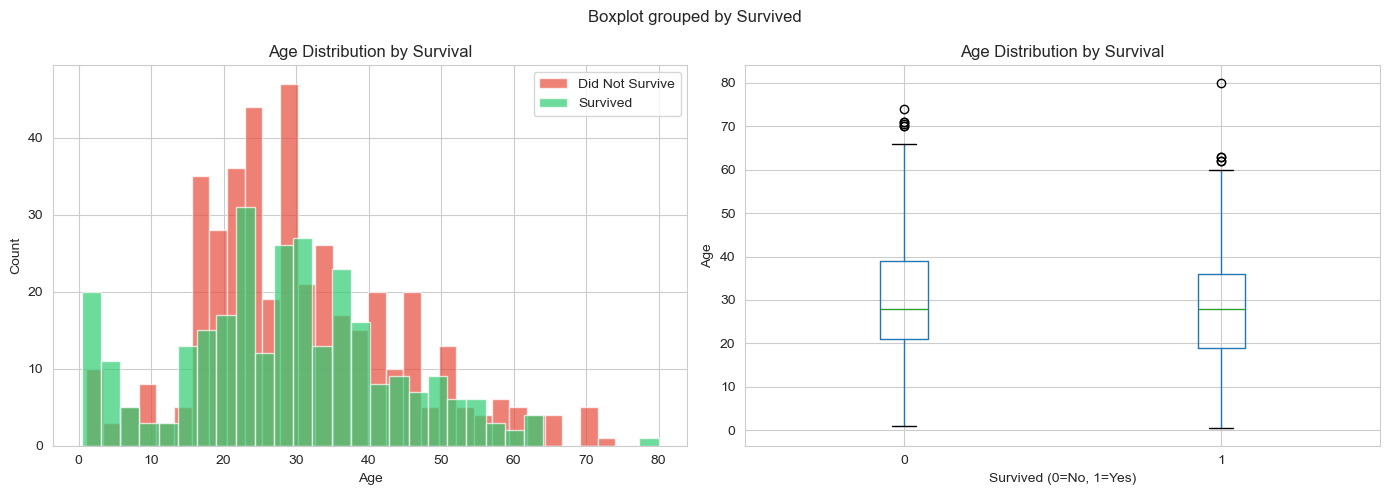

Age Statistics by Survival:
          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


In [13]:
# Age distribution by survival
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[df['Survived']==0]['Age'].dropna(), bins=30, alpha=0.7, label='Did Not Survive', color='#e74c3c')
axes[0].hist(df[df['Survived']==1]['Age'].dropna(), bins=30, alpha=0.7, label='Survived', color='#2ecc71')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Survival')
axes[0].legend()

# Box plot
df.boxplot(column='Age', by='Survived', ax=axes[1])
axes[1].set_xlabel('Survived (0=No, 1=Yes)')
axes[1].set_ylabel('Age')
axes[1].set_title('Age Distribution by Survival')

plt.tight_layout()
plt.savefig('../images/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Age Statistics by Survival:")
print(df.groupby('Survived')['Age'].describe())

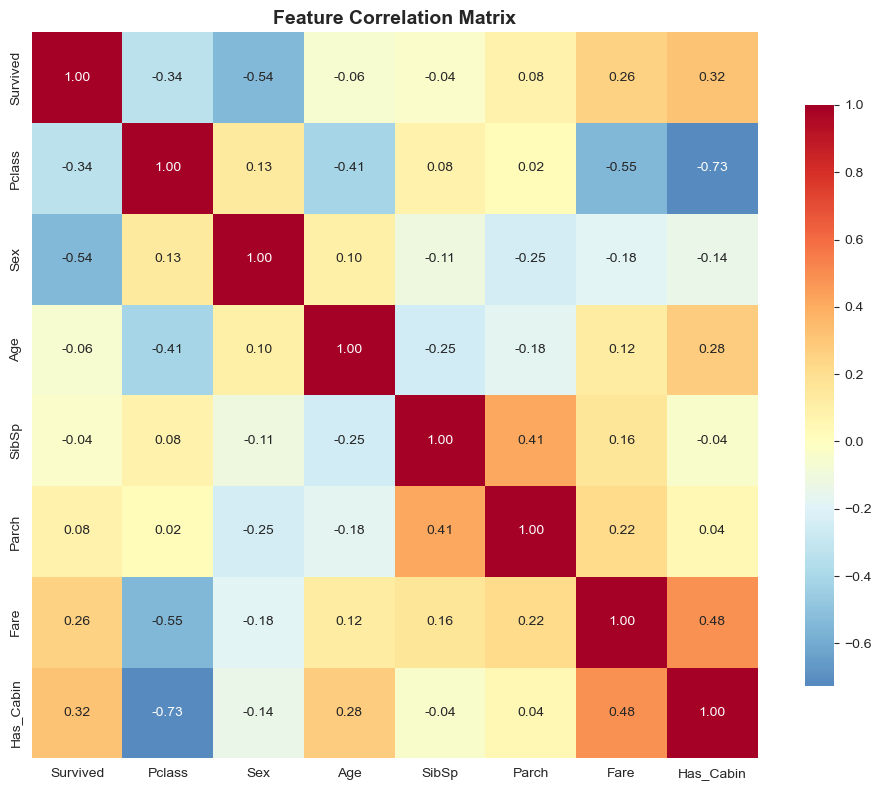

In [14]:
# Correlation heatmap
# Select numeric columns
numeric_cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin']
corr_matrix = df_processed[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering

In [31]:
# Create new features
print("Creating New Features...")

# 1. Family Size
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1

# 2. Is Alone
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)

# 3. Age Groups
df_processed['AgeGroup'] = pd.cut(df_processed['Age'], 
                                   bins=[0, 12, 18, 35, 60, 100], 
                                   labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

# 4. Fare Groups
df_processed['FareGroup'] = pd.qcut(df_processed['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Premium'])

# 5. Title from Name
df_processed['Title'] = df_processed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
df_processed['Title'] = df_processed['Title'].map(title_mapping)
df_processed['Title'] = df_processed['Title'].fillna('Rare')

# One-hot encode new categorical features
df_processed = pd.get_dummies(df_processed, columns=['AgeGroup', 'FareGroup', 'Title'], 
                              prefix=['Age', 'Fare', 'Title'])

print(" New features created!")
print(f"\nNew dataset shape: {df_processed.shape}")
print("\nNew features:")
new_features = ['FamilySize', 'IsAlone'] + [col for col in df_processed.columns if col.startswith(('Age_', 'Fare_', 'Title_'))]
for feat in new_features:
    print(f"  - {feat}")

Creating New Features...
 New features created!

New dataset shape: (891, 54)

New features:
  - FamilySize
  - IsAlone
  - Age_Child
  - Age_Teen
  - Age_Adult
  - Age_Middle
  - Age_Senior
  - Fare_Low
  - Fare_Medium
  - Fare_High
  - Fare_Premium
  - Title_Master
  - Title_Miss
  - Title_Mr
  - Title_Mrs
  - Title_Rare
  - Age_Child
  - Age_Teen
  - Age_Adult
  - Age_Middle
  - Age_Senior
  - Fare_Low
  - Fare_Medium
  - Fare_High
  - Fare_Premium
  - Title_Master
  - Title_Miss
  - Title_Mr
  - Title_Mrs
  - Title_Rare


In [16]:
# Prepare features for modeling
# Drop columns not needed for modeling
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_model = df_processed.drop(columns=columns_to_drop, errors='ignore')

# Separate features and target
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (891, 35)
Target shape: (891,)

Feature columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_T', 'Deck_U', 'FamilySize', 'IsAlone', 'Age_Child', 'Age_Teen', 'Age_Adult', 'Age_Middle', 'Age_Senior', 'Fare_Low', 'Fare_Medium', 'Fare_High', 'Fare_Premium', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [18]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print("\n Data prepared for modeling!")

Training set: (712, 35)
Testing set: (179, 35)

 Data prepared for modeling!


---
## 6. Model Training

In [20]:
# Define models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Train and evaluate models
results = {}

print("Training Models...")
print("="*60)

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC:  {roc_auc:.4f}")
    print(f"  CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print()

print("="*60)
print(" All models trained!")

Training Models...
Logistic Regression:
  Accuracy: 0.8492
  ROC-AUC:  0.8677
  CV Score: 0.8091 (+/- 0.0511)

Decision Tree:
  Accuracy: 0.7709
  ROC-AUC:  0.7577
  CV Score: 0.7641 (+/- 0.0836)

Random Forest:
  Accuracy: 0.7933
  ROC-AUC:  0.8153
  CV Score: 0.7894 (+/- 0.0729)

Gradient Boosting:
  Accuracy: 0.8212
  ROC-AUC:  0.8507
  CV Score: 0.8218 (+/- 0.0823)

SVM:
  Accuracy: 0.8212
  ROC-AUC:  0.8524
  CV Score: 0.8231 (+/- 0.0434)

K-Nearest Neighbors:
  Accuracy: 0.7709
  ROC-AUC:  0.7998
  CV Score: 0.8034 (+/- 0.0360)

Naive Bayes:
  Accuracy: 0.7207
  ROC-AUC:  0.7836
  CV Score: 0.7374 (+/- 0.1403)

 All models trained!


---
## 7. Model Evaluation

In [21]:
# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()],
    'CV Mean': [results[m]['cv_mean'] for m in results.keys()],
    'CV Std': [results[m]['cv_std'] for m in results.keys()]
})

results_df = results_df.sort_values('Accuracy', ascending=False)
print("Model Performance Summary:")
print("="*60)
print(results_df.to_string(index=False))

Model Performance Summary:
              Model  Accuracy  ROC-AUC  CV Mean   CV Std
Logistic Regression  0.849162 0.867721 0.809052 0.025527
  Gradient Boosting  0.821229 0.850659 0.821767 0.041160
                SVM  0.821229 0.852437 0.823057 0.021714
      Random Forest  0.793296 0.815349 0.789442 0.036427
      Decision Tree  0.770950 0.757708 0.764129 0.041801
K-Nearest Neighbors  0.770950 0.799802 0.803398 0.017993
        Naive Bayes  0.720670 0.783597 0.737427 0.070152


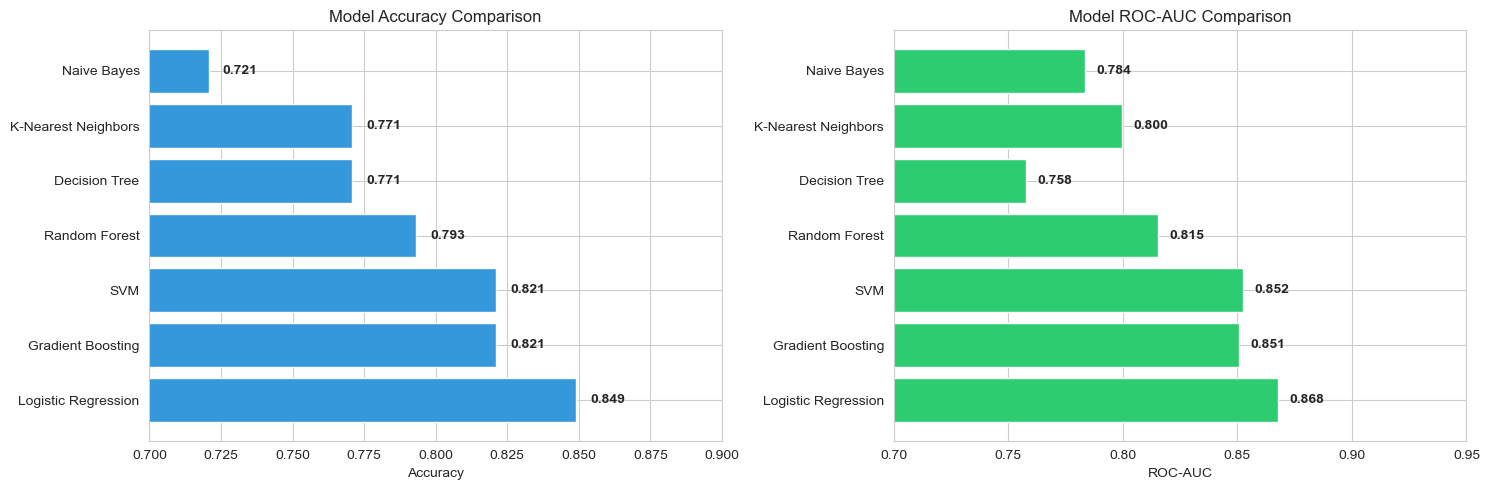

In [22]:
# Visualize model performance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy comparison
axes[0].barh(results_df['Model'], results_df['Accuracy'], color='#3498db')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlim(0.7, 0.9)
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

# ROC-AUC comparison
axes[1].barh(results_df['Model'], results_df['ROC-AUC'], color='#2ecc71')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Model ROC-AUC Comparison')
axes[1].set_xlim(0.7, 0.95)
for i, v in enumerate(results_df['ROC-AUC']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Best model analysis
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"Best Model: {best_model_name}")
print("="*60)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, best_predictions, target_names=['Did Not Survive', 'Survived']))

Best Model: Logistic Regression

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.87      0.89      0.88       110
       Survived       0.82      0.78      0.80        69

       accuracy                           0.85       179
      macro avg       0.84      0.84      0.84       179
   weighted avg       0.85      0.85      0.85       179



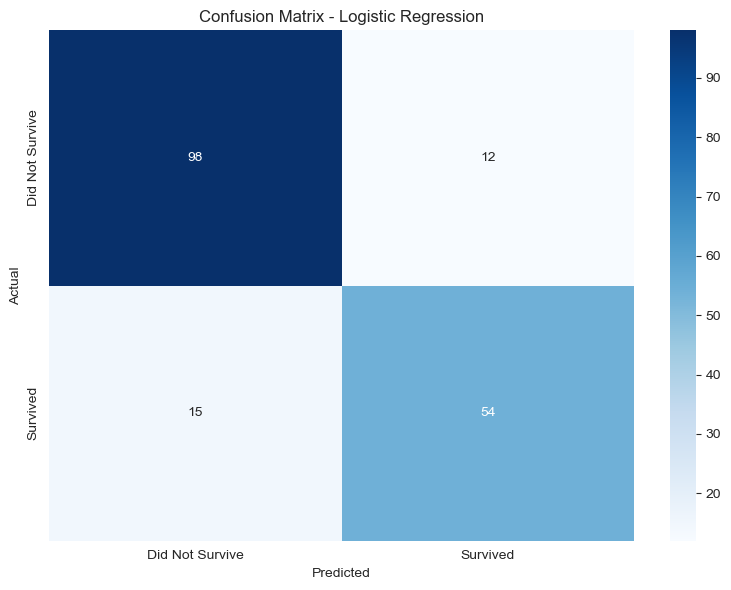


True Negatives: 98
False Positives: 12
False Negatives: 15
True Positives: 54


In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

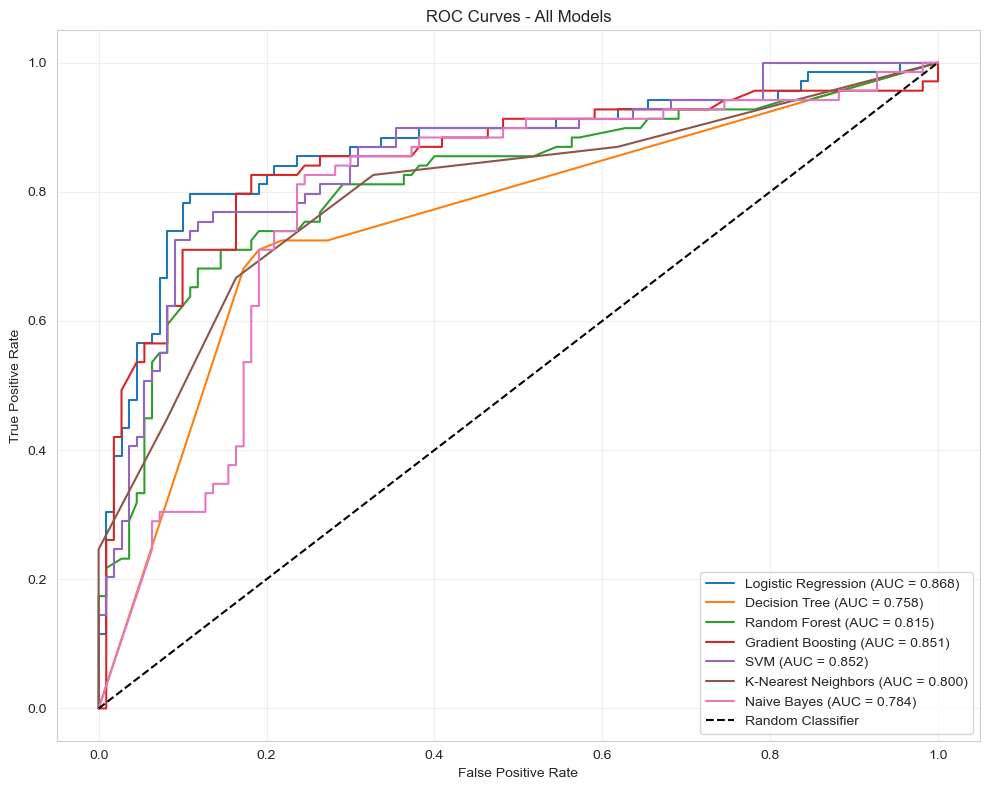

In [25]:
# ROC Curve for all models
plt.figure(figsize=(10, 8))

for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
    auc = results[name]['roc_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.tight_layout()
    plt.savefig('../images/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Top 10 Important Features:")
    print(feature_importance.head(10).to_string(index=False))
else:
    print(f"{best_model_name} does not provide feature importances.")

Logistic Regression does not provide feature importances.


---
## 8. Hyperparameter Tuning (Optional)

In [28]:
# Hyperparameter tuning for Random Forest (example)
print("Hyperparameter Tuning for Random Forest...")

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

# Uncomment to run (may take a few minutes)
# grid_search.fit(X_train_scaled, y_train)
# print(f"\nBest Parameters: {grid_search.best_params_}")
# print(f"Best CV Score: {grid_search.best_score_:.4f}")

print("\n Uncomment the code above to run hyperparameter tuning")
print("   (This may take several minutes)")

Hyperparameter Tuning for Random Forest...

 Uncomment the code above to run hyperparameter tuning
   (This may take several minutes)


---
## 9. Save Model & Make Predictions

In [29]:
import pickle

# Save the best model
model_filename = f'../models/{best_model_name.replace(" ", "_").lower()}_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

# Save the scaler
scaler_filename = '../models/scaler.pkl'
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)

# Save feature columns
feature_columns_filename = '../models/feature_columns.pkl'
with open(feature_columns_filename, 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print(f" Model saved: {model_filename}")
print(f" Scaler saved: {scaler_filename}")
print(f" Feature columns saved: {feature_columns_filename}")

 Model saved: ../models/logistic_regression_model.pkl
 Scaler saved: ../models/scaler.pkl
 Feature columns saved: ../models/feature_columns.pkl


In [30]:
# Create a sample prediction function
def predict_survival(passenger_data, model, scaler, feature_columns):
    """
    Predict survival for a new passenger.
    
    Parameters:
    -----------
    passenger_data : dict
        Dictionary containing passenger information
    model : trained model
    scaler : fitted StandardScaler
    feature_columns : list of feature column names
    
    Returns:
    --------
    prediction : int (0 = Did not survive, 1 = Survived)
    probability : float (probability of survival)
    """
    # Convert to DataFrame
    df_pred = pd.DataFrame([passenger_data])
    
    # Ensure all required columns are present
    for col in feature_columns:
        if col not in df_pred.columns:
            df_pred[col] = 0
    
    # Reorder columns
    df_pred = df_pred[feature_columns]
    
    # Scale features
    df_pred_scaled = scaler.transform(df_pred)
    
    # Predict
    prediction = model.predict(df_pred_scaled)[0]
    probability = model.predict_proba(df_pred_scaled)[0][1]
    
    return prediction, probability

# Example usage
print("Example Prediction Function:")
print("="*60)
print(predict_survival.__doc__)

Example Prediction Function:

Predict survival for a new passenger.

Parameters:
-----------
passenger_data : dict
    Dictionary containing passenger information
model : trained model
scaler : fitted StandardScaler
feature_columns : list of feature column names

Returns:
--------
prediction : int (0 = Did not survive, 1 = Survived)
probability : float (probability of survival)

